## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ahlam Idris

**Date:** 09/30/2026

# Your Phase 1 solution to the problem goes here.
q#1

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [15]:
df = pd.read_csv("land_mines.csv")
print(df.head())
print(df.info())
print(df.isna().sum())
print(df.describe())

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0


Target distribution:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature means by mine type:
            voltage              height                soil          
               mean       std      mean       std      mean       std
mine_type                                                            
1          0.296463  0.031672  0.495519  0.315962  0.492958  0.341143
2          0.721123  0.222267  0.487013  0.310720  0.508571  0.345045
3          0.402408  0.098185  0.527548  0.296288  0.496970  0.351248
4          0.345365  0.092564  0.506887  0.306348  0.503030  0.347727
5          0.379598  0.076340  0.530070  0.306426  0.516923  0.346216


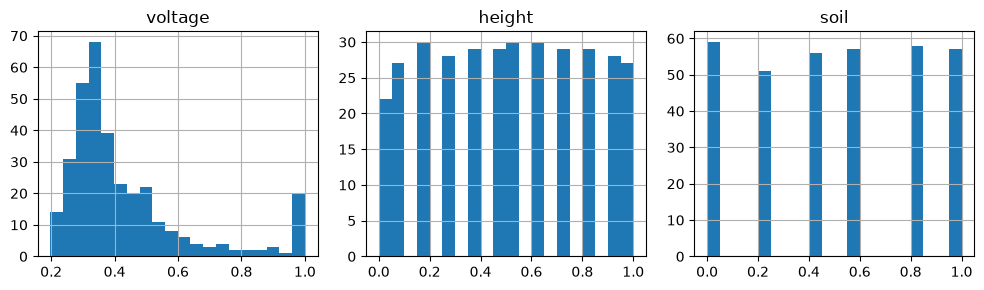

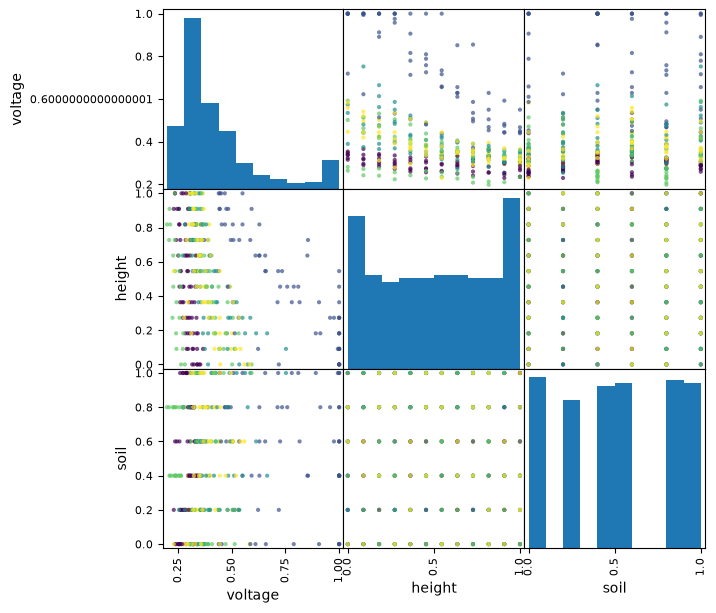

In [54]:
print("\nTarget distribution:")
print(df["mine_type"].value_counts().sort_index())
 
print("\nFeature means by mine type:")
print(df.groupby("mine_type")[["voltage", "height", "soil"]].agg(["mean", "std"]))
 
df[["voltage", "height", "soil"]].hist(bins=20, figsize=(10, 3), layout=(1, 3))
plt.tight_layout()
plt.show()
 
pd.plotting.scatter_matrix(df[["voltage", "height", "soil"]], c=df["mine_type"],
                           figsize=(7, 7), alpha=0.7)
plt.show()

In [55]:
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

In [56]:
scaler = StandardScaler().fit(X_train)
Xtr, Xte = scaler.transform(X_train), scaler.transform(X_test)


Best k = 1, test accuracy = 0.509


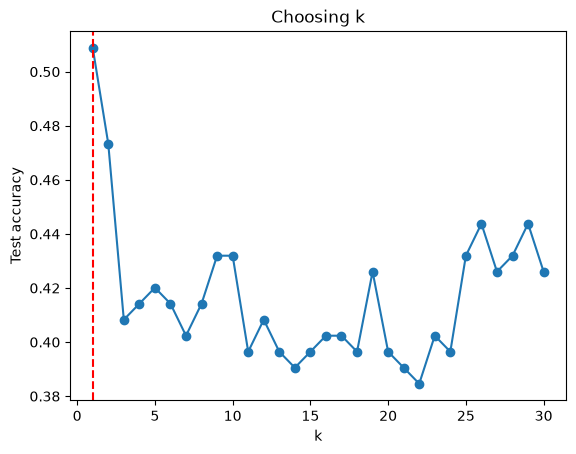

In [32]:
ks = range(1, 31)
accs = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(Xtr, y_train)
    accs.append(accuracy_score(y_test, model.predict(Xte)))
 
best_k = list(ks)[int(np.argmax(accs))]
print(f"\nBest k = {best_k}, test accuracy = {max(accs):.3f}")
 
plt.plot(list(ks), accs, marker="o")
plt.axvline(best_k, color="red", ls="--")
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("Choosing k")
plt.show()

In [57]:
best = KNeighborsClassifier(n_neighbors=best_k).fit(Xtr, y_train)
pred = best.predict(Xte)
print(pd.crosstab(y_test, pred, rownames=["Actual"], colnames=["Predicted"]))
print("\nOverall accuracy:", accuracy_score(y_test, pred))
# precision = accuracy of predictions FOR a class; recall = how many of a class we catch
print(classification_report(y_test, pred))

Predicted   1   2   3   4  5
Actual                      
1          22   0   3   3  8
2           0  32   0   3  0
3           7   0  10   9  7
4           6   5   4  13  5
5           6   0  10   7  9

Overall accuracy: 0.5088757396449705
              precision    recall  f1-score   support

           1       0.54      0.61      0.57        36
           2       0.86      0.91      0.89        35
           3       0.37      0.30      0.33        33
           4       0.37      0.39      0.38        33
           5       0.31      0.28      0.30        32

    accuracy                           0.51       169
   macro avg       0.49      0.50      0.49       169
weighted avg       0.50      0.51      0.50       169



In [58]:
from sklearn.preprocessing import MinMaxScaler

In [43]:
from sklearn.model_selection import train_test_split

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["voltage"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.20, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

In [59]:
from sklearn.neighbors import KNeighborsRegressor

In [60]:
eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsRegressor(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
        (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
        (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

q1

1. What is the difference between regression and classification?
The difference between regression and classification are that regression predicts continuous numbers like for example, price while classification predicts a category like mine type. Regression predicts a continuous numeric outcome such as baseline sales while the classification predicts a category like a class.

2. What is a confusion table? What does it help us understand about a model's performance?
A confusion table is a grid that contains actual and predicted classes and it demonstrates the overall accuracy by displaying which classes are well versus which ones get confused with one another.


3. What does the SSE quantify about a particular model?
The SSE quantifies the sum of squared differences between actual and predicted values. The SSE also measures the particular model's total prediction error and we know that the lower the value the better.


4. What are overfitting and underfitting?
Overfitting is when the model will fit into the noise of the training data but it doesn't do well with performing on the new data because the k value is too small. Underfitting is when the model is too simple to fully get the full picture of the pattern so it will also perform poorly because the k value is too large. A very small k can overfit noise in the training data while a very large k can underfit by giving nearly the same prediction for every observation.


5. Why does splitting the data into training and testing sets, and choosing by evaluating accuracy or SSE on the test set, improve model performance?
Splitting the data into training and testing sets improves the model performance because the model has already seen error on the training data so testing on held out data allows us to get a more accurate estimate on the performance of the new data. So it's training error is overly optimistic and we are choosing the k value that picks the value that will generalize best instead of one that would overfit. We split the data so that we can check how well the model predicts new observations like how it fit models on a training set, compares their predictions with a separate validation set, and keeps a test set for the final evaluation when one is available. This validation error helps estimate performance on future data from a similar source and the estimate depends on how we split the data up.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
The strengths of labeling is that it is simple and can be acted on easily and probabilities demonstrate the uncertainty which allows us to set up our own decision threshold. Some weakneses for labeling at that it hides how confident the model actually is and for probability, it is harder to interpret as well as it can be poorly calculated for kNN with small k values.

q2
This is a case study on k nearest neighbor classification, using the land_mines.csv data.

The data consists of a label, mine_type, taking integer values 1 to 5, and three properties of the mine, voltage, height and soil. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a k-NN classifier. Explain how you select k.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.


1. 
I loaded the csv file and explored the data by testing out different commands like df.head(), df.info(), df.isna().sum() and these commands allowed me to assess the data and assure that it was clean so that I can make an analysis. After doing that part of the EDA, I found that there are 338 rows, 3 numeric features like voltage, soil, and height and that the label mine_type didn't have any missing values in any column. I found that the features were on a 0 to 1 scale and that the classes are balanced so the accuracy seems like a fair assessment and the stratified split works well in this circumstance. Voltage seems to differ between types while height and soil are about average for each type. This helped me see how each feature's shape and classes intersect with one another.

2. 
I split the data 50/50 into 169 training and 169 testing rows and I stratified by mine_type so that every class appeared in both halves.

3. 
I standardized the features using the training set only, because k-NN is based on distance and we shouldn't let one feature dominate/overpower. From there I tried every k from 1 to 30 on the training set and measured its accuracy. I selected my k based on the highest testing accuracy and that proved to be k=1. Having a large k value makes it hard to differentiate between the classes because it would be underfitting, while have a small k value would follow the local pattern more closely.



4. 
The overall accuracy of the confusion table is roughly 51% which deemed higher than the expected 20% from random guessing among 5 types. The table shows that the model seems to be the most accurate for type 2 beacuse the voltage level is very different from the other ones. It is okay for type 1 but it loses accuracy for types 3, 4, and 5 because they get confused for each other as their voltage values have lots of overlap.


5. 
I'd explain that a model can be accurate for a type, however it can still make many mistages because many other mines can also get predicted as that same type which means there is low precision. For instance, type 1 has about 61% recall but only 54% of type 1 predictions are actually accurate so it goes to show that the model should simply be used as a guide. Don't use the model as a final answer but rather as a framework to help you analyze the data types.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]